# Global IKEA Pricing & Product Value Analysis

## Project Overview

IKEA sells many of the same products across international markets, but prices,
customer ratings, and review activity can vary substantially across countries.

This project analyzes IKEA's global product catalog to investigate how prices
vary for comparable products across markets and to identify products that offer
strong customer value relative to similar products.

Rather than comparing products only on raw price or average rating, the analysis
accounts for international pricing differences, product category, customer review
volume, and the reliability of product ratings.

## Research Questions

1. How much do prices for the same IKEA products vary across countries?
2. Which countries tend to price comparable IKEA products above or below their
   international median price?
3. Is product price associated with customer rating after accounting for review
   volume and market differences?
4. Which IKEA products provide the strongest customer value relative to similar
   products in the same market and category?

## Analytical Strategy

The analysis will:

1. Audit and clean the global IKEA catalog.
2. Standardize international prices into USD.
3. Distinguish product country listings from unique products.
4. Compare identical products across international markets.
5. Adjust customer ratings for review volume.
6. Develop a category relative customer value score.
7. Use statistical modeling to evaluate the price rating relationship.
8. Test whether changing analysis choices still reach the same conclusion.
9. Export a processed dataset for an interactive Tableau dashboard.

In [44]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pdfplumber

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

In [46]:
pdf_path = "../data/external/Rates_of_Exchange_03312026.pdf"

rows = []

with pdfplumber.open(pdf_path) as pdf:
    # Skip page 1 because it is only the cover page
    for page in pdf.pages[1:]:
        table = page.extract_table()

        for row in table:
            if len(row) == 3 and row[2] == "3/31/2026":
                rows.append(row)


In [3]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "IKEA_product_catalog.csv"
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

RAW_DATA_PATH

PosixPath('/Users/andrewzhou/Desktop/ikea-global-pricing-analysis/data/raw/IKEA_product_catalog.csv')

In [4]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {RAW_DATA_PATH.resolve()}"
    )

In [5]:
ikea_raw = pd.read_csv(
    RAW_DATA_PATH,
    low_memory=False
)

ikea_raw.head()

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,none,NONE,Canada


In [6]:
ikea_raw.shape

(401046, 18)

## 2. Understanding the Unit of Analysis

The dataset contains product listings from multiple IKEA markets. A single
`product_id` may therefore appear multiple times because the same product is
sold in multiple countries.

For this project:

- `unique_id` represents a product and the country that its from.
- `product_id` identifies the IKEA product.
- One product can have multiple observations because of different countries.

Each row is a combination of one product and one country. 

The distinction between these two categories is important because I will compare products with the same product ID but different unique ID's to compare prices across country. But, I'll combine country listing for the same product when ranking products globally. 

## 3. Data Audit

In [7]:
ikea_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 401046 entries, 0 to 401045
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   unique_id             401046 non-null  str    
 1   product_id            401046 non-null  int64  
 2   product_name          401046 non-null  str    
 3   product_type          401046 non-null  str    
 4   product_measurements  401046 non-null  str    
 5   product_description   401046 non-null  str    
 6   main_category         401046 non-null  str    
 7   sub_category          401046 non-null  str    
 8   product_rating        401046 non-null  str    
 9   product_rating_count  401046 non-null  str    
 10  badge                 401046 non-null  str    
 11  online_sellable       401046 non-null  bool   
 12  url                   401046 non-null  str    
 13  price                 401046 non-null  float64
 14  currency              401046 non-null  str    
 15  discount   

In [8]:
ikea_raw.head()

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.3,140.0,none,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,none,NONE,Australia
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.3,6.0,none,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,none,NONE,Austria
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.0,1.0,none,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,none,NONE,Bahrain
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,none,NONE,Belgium
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.7,543.0,none,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,none,NONE,Canada


In [9]:
ikea_raw.dtypes

unique_id                   str
product_id                int64
product_name                str
product_type                str
product_measurements        str
product_description         str
main_category               str
sub_category                str
product_rating              str
product_rating_count        str
badge                       str
online_sellable            bool
url                         str
price                   float64
currency                    str
discount                    str
sale_tag                    str
country                     str
dtype: object

In [10]:
ikea_raw.describe()

,product_id,price
count,"401,046.000","401,046.000"
mean,"49,221,846.838","14,900.415"
std,"29,819,926.476","127,424.026"
min,"28,508.000",0.100
25%,"20,582,238.000",21.990
50%,"50,404,918.000",149.000
75%,"79,281,790.000",990.000
max,"99,931,625.000","9,999,990.000"


In [11]:
ikea_raw.nlargest(10, "price")

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country
303892,80245051-Colombia,80245051,STOCKHOLM,Sofá 3 puestos,none,"STOCKHOLM Sofá 3 puestos, Seglora beige",sofas-sillones,sofas,4.3,6.0,TOP_SELLER,True,https://www.ikea.com/co/es/p/stockholm-sofa-3-...,"9,999,990.000",COP,none,NONE,Colombia
210494,59477359-Colombia,59477359,VIMLE,Sofá en L 3 puestos,none,"VIMLE Sofá en L 3 puestos, Grann/Bomstad negro",camas-colchones,camas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-en-l-3...,"9,599,980.000",COP,none,TIME_RESTRICTED_OFFER,Colombia
374435,9306708-Colombia,9306708,VIMLE,Sofá 4 puestos,none,"VIMLE Sofá 4 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-4-pues...,"9,499,990.000",COP,none,NEW_LOWER_PRICE,Colombia
296977,79554276-Colombia,79554276,LANDSKRONA,Sofá de 4 puestos con chaiselongues,none,LANDSKRONA Sofá de 4 puestos con chaiselongues...,sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/landskrona-sofa-d...,"9,299,990.000",COP,none,NEW_LOWER_PRICE,Colombia
116282,39443191-Colombia,39443191,KIVIK,Sofá 4 puestos,none,"KIVIK Sofá 4 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/kivik-sofa-4-pues...,"8,499,990.000",COP,none,NONE,Colombia
335574,89443184-Colombia,89443184,KIVIK,Sofá 3 puestos,none,"KIVIK Sofá 3 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,none,True,https://www.ikea.com/co/es/p/kivik-sofa-3-pues...,"7,999,990.000",COP,none,NONE,Colombia
374395,9306261-Colombia,9306261,VIMLE,Sofá 3 puestos,none,"VIMLE Sofá 3 puestos, Con chaiselongue con apo...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-3-pues...,"7,499,990.000",COP,none,NEW_LOWER_PRICE,Colombia
332338,89306686-Colombia,89306686,VIMLE,Sofá 3 puestos,none,"VIMLE Sofá 3 puestos, Con chaiselongue/Grann/B...",sofas-sillones,sofas,none,none,TOP_SELLER,True,https://www.ikea.com/co/es/p/vimle-sofa-3-pues...,"7,199,990.000",COP,none,NEW_LOWER_PRICE,Colombia
118519,39534902-Colombia,39534902,HAVSTA,Combi almacenaje puertas vidrio,243x47x212 cm,"HAVSTA Combi almacenaje puertas vidrio, blanco...",almacenamiento-organizacion,vitrinas-almacenamiento,5.0,1.0,none,True,https://www.ikea.com/co/es/p/havsta-combi-alma...,"7,199,940.000",COP,none,NEW_LOWER_PRICE,Colombia
365736,90586092-Colombia,90586092,STOCKHOLM 2025,Sofá 3 puestos,none,"STOCKHOLM 2025 Sofá 3 puestos, Sundhamn beige",sofas-sillones,sofas,5.0,2.0,none,True,https://www.ikea.com/co/es/p/stockholm-2025-so...,"6,999,990.000",COP,none,NONE,Colombia


In [12]:
ikea_raw.product_rating.unique()

<StringArray>
[ '3.3',  '1.0',  '3.7',  '4.0',  '4.8',  '4.5',  '4.2',  '1.5',  '3.8',
 'none',  '4.4',  '3.9',  '4.3',  '4.1',  '4.6',  '4.9',  '4.7',  '5.0',
  '2.5',  '3.0',  '3.1',  '3.5',  '2.0',  '3.6',  '1.3',  '3.4',  '2.7',
  '2.3',  '2.6',  '2.4',  '1.7',  '3.2',  '2.8',  '2.1',  '2.9',  '1.8',
  '1.4',  '2.2',  '1.9',  '1.6',  '1.2']
Length: 41, dtype: str

In [13]:
ikea_raw.product_rating_count.value_counts()

product_rating_count
none      131960
1.0        32080
2.0        18975
3.0        13402
4.0        10597
           ...  
705.0          1
1621.0         1
581.0          1
1092.0         1
854.0          1
Name: count, Length: 1453, dtype: int64

In [14]:
ikea_raw.currency.unique()

<StringArray>
['AUD', 'EUR', 'BHD', 'CAD', 'CLP', 'COP', 'CZK', 'DKK', 'EGP', 'HUF', 'INR',
 'JPY', 'JOD', 'KWD', 'MYR', 'MXN', 'MAD', 'NZD', 'NOK', 'OMR', 'PHP', 'PLN',
 'QAR', 'RON', 'SAR', 'RSD', 'SGD', 'KRW', 'SEK', 'CHF', 'THB', 'AED', 'GBP',
 'USD']
Length: 34, dtype: str

In [15]:
audit_summary = pd.Series({
    "Rows": len(ikea_raw),
    "Columns": ikea_raw.shape[1],
    "Unique listing IDs": ikea_raw["unique_id"].nunique(),
    "Unique products": ikea_raw["product_id"].nunique(),
    "Countries": ikea_raw["country"].nunique(),
    "Currencies": ikea_raw["currency"].nunique(),
    "Main categories": ikea_raw["main_category"].nunique(),
    "Exact duplicate rows": ikea_raw.duplicated().sum(),
    "Duplicate unique IDs": ikea_raw["unique_id"].duplicated().sum()
})

audit_summary

Rows                    401046
Columns                     18
Unique listing IDs      401046
Unique products          34932
Countries                   46
Currencies                  34
Main categories            314
Exact duplicate rows         0
Duplicate unique IDs         0
dtype: int64

In [16]:
ikea_raw.isna().sum().sort_values(ascending=False)

unique_id               0
product_id              0
sale_tag                0
discount                0
currency                0
price                   0
url                     0
online_sellable         0
badge                   0
product_rating_count    0
product_rating          0
sub_category            0
main_category           0
product_description     0
product_measurements    0
product_type            0
product_name            0
country                 0
dtype: int64

In [17]:
ikea_raw.country.unique()

<StringArray>
[     'Australia',        'Austria',        'Bahrain',        'Belgium',
         'Canada',          'Chile',       'Colombia',        'Croatia',
 'Czech_Republic',        'Denmark',          'Egypt',        'Finland',
         'France',        'Germany',        'Hungary',          'India',
        'Ireland',          'Italy',          'Japan',         'Jordan',
         'Kuwait',       'Malaysia',         'Mexico',        'Morocco',
    'Netherlands',    'New_Zealand',         'Norway',           'Oman',
    'Philippines',         'Poland',       'Portugal',          'Qatar',
        'Romania',   'Saudi_Arabia',         'Serbia',      'Singapore',
       'Slovakia',       'Slovenia',    'South_Korea',          'Spain',
         'Sweden',    'Switzerland',       'Thailand',            'UAE',
             'UK',            'USA']
Length: 46, dtype: str

In [18]:
product_country_counts = (
    ikea_raw
    .groupby("product_id")["country"]
    .nunique()
)

product_country_counts.describe()

count   34,932.000
mean        11.481
std         13.842
min          1.000
25%          1.000
50%          5.000
75%         17.000
max         46.000
Name: country, dtype: float64

In [19]:
product_country_counts.sort_values(
    ascending=False
).head(20)

product_id
28508       46
30366917    46
30468119    46
30455089    46
30454004    46
30444468    46
30443930    46
30432502    46
30424385    46
30408979    46
30404028    46
30373588    46
30333583    46
30485350    46
30333125    46
30328534    46
30326177    46
30298396    46
30258913    46
30213552    46
Name: country, dtype: int64

### Data Audit Findings

- The dataset contains approximately 401,046 product country listings representing
  34,932 unique IKEA products across 46 countries.
- Individual products often appear in multiple countries, confirming that
  `unique_id` and `product_id` represent different units.
- Several columns use textual missing value indicators such as `"none"` rather
  than true null values. Need to convert.
- International prices are stored in local currencies and cannot be compared
  directly.
- The number of countries in which a product appears varies substantially, so
  international price comparisons should require a minimum amount of countries where the product is sold.

## 4. Data Cleaning

In [20]:
ikea = ikea_raw.copy()

In [21]:
object_cols = ikea.select_dtypes(include="object").columns
for col in object_cols:
    ikea[col] = ikea[col].astype("string").str.strip()

/var/folders/qq/ks2t1rdj67sc37gvntd7qmfh0000gn/T/ipykernel_56834/1893608895.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = ikea.select_dtypes(include="object").columns


In [22]:
missing_tokens = ["none","NONE","None","", " "]
ikea[object_cols] = (ikea[object_cols].replace(missing_tokens, np.nan))

In [23]:
ikea["product_rating"] = pd.to_numeric(ikea["product_rating"],errors="coerce")
ikea["product_rating_count"] = pd.to_numeric(ikea["product_rating_count"], errors="coerce")
ikea["price"] = pd.to_numeric(ikea["price"],errors="coerce")

In [24]:
ikea[["product_rating","product_rating_count","price"]].dtypes

product_rating          Float64
product_rating_count    Float64
price                   float64
dtype: object

In [25]:
ikea["product_rating"].describe()

count   269,086.000
mean          4.455
std           0.618
min           1.000
25%           4.300
50%           4.600
75%           4.800
max           5.000
Name: product_rating, dtype: Float64

In [26]:
ikea[ikea["product_rating"].notna() & ~ikea["product_rating"].between(1, 5)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [27]:
ikea["price"].describe()

count     401,046.000
mean       14,900.415
std       127,424.026
min             0.100
25%            21.990
50%           149.000
75%           990.000
max     9,999,990.000
Name: price, dtype: float64

In [28]:
ikea[ikea["price"].notna() & (ikea["price"] <= 0)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [29]:
ikea["product_rating_count"].describe()

count   269,086.000
mean        181.287
std         592.599
min           1.000
25%           4.000
50%          18.000
75%          98.000
max      10,058.000
Name: product_rating_count, dtype: Float64

In [30]:
ikea[ikea["product_rating_count"].notna() & (ikea["product_rating_count"] < 0)]

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country


In [31]:
ikea_raw.currency.unique()

<StringArray>
['AUD', 'EUR', 'BHD', 'CAD', 'CLP', 'COP', 'CZK', 'DKK', 'EGP', 'HUF', 'INR',
 'JPY', 'JOD', 'KWD', 'MYR', 'MXN', 'MAD', 'NZD', 'NOK', 'OMR', 'PHP', 'PLN',
 'QAR', 'RON', 'SAR', 'RSD', 'SGD', 'KRW', 'SEK', 'CHF', 'THB', 'AED', 'GBP',
 'USD']
Length: 34, dtype: str

In [32]:
ikea["currency"].dropna().sort_values().unique()

<StringArray>
['AED', 'AUD', 'BHD', 'CAD', 'CHF', 'CLP', 'COP', 'CZK', 'DKK', 'EGP', 'EUR',
 'GBP', 'HUF', 'INR', 'JOD', 'JPY', 'KRW', 'KWD', 'MAD', 'MXN', 'MYR', 'NOK',
 'NZD', 'OMR', 'PHP', 'PLN', 'QAR', 'RON', 'RSD', 'SAR', 'SEK', 'SGD', 'THB',
 'USD']
Length: 34, dtype: string

In [ ]:
exchange_rates = pd.DataFrame(
    rows,
    columns=[
        "country_currency",
        "foreign_currency_per_usd",
        "rate_date"
    ]
)

exchange_rates.head()

,country_currency,foreign_currency_per_usd,rate_date
0,Afghanistan-Afghani,64.7700,3/31/2026
1,Albania-Lek,83.3000,3/31/2026
2,Algeria-Dinar,132.5960,3/31/2026
3,Angola-Kwanza,912.1300,3/31/2026
4,Antigua & Barbuda-E. Caribbean Dollar,2.7000,3/31/2026


In [47]:
exchange_rates["foreign_currency_per_usd"] = pd.to_numeric(
    exchange_rates["foreign_currency_per_usd"].str.replace(",", "", regex=False)
)

exchange_rates["rate_date"] = pd.to_datetime(
    exchange_rates["rate_date"]
)

In [48]:
exchange_rates["usd_per_currency"] = (
    1 / exchange_rates["foreign_currency_per_usd"]
)

In [49]:
exchange_rates

,country_currency,foreign_currency_per_usd,rate_date,usd_per_currency
0,Afghanistan-Afghani,64.770,2026-03-31,0.015
1,Albania-Lek,83.300,2026-03-31,0.012
2,Algeria-Dinar,132.596,2026-03-31,0.008
3,Angola-Kwanza,912.130,2026-03-31,0.001
4,Antigua & Barbuda-E. Caribbean Dollar,2.700,2026-03-31,0.370
...,...,...,...,...
160,Vietnam-Dong,"26,323.000",2026-03-31,0.000
161,Western Samoa-Tala,2.667,2026-03-31,0.375
162,Yemen-Rial,528.000,2026-03-31,0.002
163,Zambia-New Kwacha,19.135,2026-03-31,0.052


In [50]:
currency_map = {
    "Australia-Dollar": "AUD",
    "Euro Zone-Euro": "EUR",
    "Bahrain-Dinar": "BHD",
    "Canada-Dollar": "CAD",
    "Chile-Peso": "CLP",
    "Colombia-Peso": "COP",
    "Czech Republic-Koruna": "CZK",
    "Denmark-Krone": "DKK",
    "Egypt-Pound": "EGP",
    "Hungary-Forint": "HUF",
    "India-Rupee": "INR",
    "Japan-Yen": "JPY",
    "Jordan-Dinar": "JOD",
    "Kuwait-Dinar": "KWD",
    "Malaysia-Ringgit": "MYR",
    "Mexico-Peso": "MXN",
    "Morocco-Dirham": "MAD",
    "New Zealand-Dollar": "NZD",
    "Norway-Krone": "NOK",
    "Oman-Rial": "OMR",
    "Philippines-Peso": "PHP",
    "Poland-Zloty": "PLN",
    "Qatar-Riyal": "QAR",
    "Romania-New Leu": "RON",
    "Saudi Arabia-Riyal": "SAR",
    "Serbia-Dinar": "RSD",
    "Singapore-Dollar": "SGD",
    "Korea-Won": "KRW",
    "Sweden-Krona": "SEK",
    "Switzerland-Franc": "CHF",
    "Thailand-Baht": "THB",
    "United Arab Emirates-Dirham": "AED",
    "United Kingdom-Pound": "GBP"
}

In [51]:
ikea_exchange_rates = exchange_rates[
    exchange_rates["country_currency"].isin(currency_map)
].copy()

ikea_exchange_rates["currency"] = (
    ikea_exchange_rates["country_currency"].map(currency_map)
)

In [52]:
ikea_exchange_rates = ikea_exchange_rates[
    ["currency", "usd_per_currency", "rate_date"]
]

ikea_exchange_rates

,currency,usd_per_currency,rate_date
7,AUD,0.688,2026-03-31
10,BHD,2.653,2026-03-31
26,CAD,0.718,2026-03-31
31,CLP,0.001,2026-03-31
33,COP,0.000,2026-03-31
41,CZK,0.048,2026-03-31
43,DKK,0.154,2026-03-31
47,EGP,0.018,2026-03-31
53,EUR,1.149,2026-03-31
67,HUF,0.003,2026-03-31


In [53]:
usd_row = pd.DataFrame({
    "currency": ["USD"],
    "usd_per_currency": [1.0],
    "rate_date": [pd.Timestamp("2026-03-31")]
})

ikea_exchange_rates = pd.concat(
    [ikea_exchange_rates, usd_row],
    ignore_index=True
)

In [54]:
ikea_currencies = set(ikea["currency"].dropna().unique())
fx_currencies = set(ikea_exchange_rates["currency"])

ikea_currencies - fx_currencies

set()

## Merge Exchange Rates and Convert Prices to USD

In [58]:
ikea["price"].dtype

dtype('float64')

In [59]:
ikea["price"] = pd.to_numeric(
    ikea["price"],
    errors="coerce"
)

In [60]:
ikea = ikea.merge(
    ikea_exchange_rates[
        ["currency", "usd_per_currency", "rate_date"]
    ],
    on="currency",
    how="left",
    validate="many_to_one"
)

In [61]:
ikea["usd_per_currency"].isna().sum()

np.int64(0)

In [62]:
ikea.loc[
    ikea["usd_per_currency"].isna(),
    "currency"
].value_counts()

Series([], Name: count, dtype: int64)

In [63]:
ikea["price_usd"] = (
    ikea["price"] *
    ikea["usd_per_currency"]
)

In [64]:
ikea[
    [
        "country",
        "currency",
        "price",
        "usd_per_currency",
        "price_usd"
    ]
].head(20)

,country,currency,price,usd_per_currency,price_usd
0,Australia,AUD,30.000,0.688,20.647
1,Austria,EUR,27.990,1.149,32.172
2,Bahrain,BHD,9.500,2.653,25.199
3,Belgium,EUR,29.990,1.149,34.471
4,Canada,CAD,34.990,0.718,25.118
5,Chile,CLP,"26,990.000",0.001,29.123
6,Colombia,COP,"139,990.000",0.000,38.184
7,Croatia,EUR,19.990,1.149,22.977
8,Czech_Republic,CZK,699.000,0.048,33.565
9,Denmark,DKK,199.000,0.154,30.611


In [66]:
ikea.loc[
    ikea["currency"] == "USD",
    ["price", "usd_per_currency", "price_usd"]
].head()

,price,usd_per_currency,price_usd
45,34.990,1.000,34.990
115,4.990,1.000,4.990
128,12.990,1.000,12.990
170,65.000,1.000,65.000
216,59.000,1.000,59.000


In [67]:
ikea["price_usd"].describe()

count   401,046.000
mean        177.979
std         324.251
min           0.179
25%          10.614
50%          41.253
75%         195.402
max       7,482.749
Name: price_usd, dtype: float64

In [68]:
ikea["price_usd"].isna().sum()

np.int64(0)

In [69]:
ikea.loc[
    ikea["price_usd"] <= 0,
    ["product_name", "country", "currency", "price", "price_usd"]
]

,product_name,country,currency,price,price_usd


In [70]:
ikea.to_csv(
    PROCESSED_DATA_DIR / "ikea_cleaned.csv",
    index=False
)

In [71]:
price_df = ikea.dropna(
    subset=[
        "unique_id",
        "product_id",
        "country",
        "price_usd"
    ]
).copy()

In [81]:
price_df

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,usd_per_currency,rate_date,price_usd,n_markets
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.300,140.000,<NA>,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,<NA>,<NA>,Australia,0.688,2026-03-31,20.647,46
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.300,6.000,<NA>,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,<NA>,<NA>,Austria,1.149,2026-03-31,32.172,46
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.000,1.000,<NA>,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,<NA>,<NA>,Bahrain,2.653,2026-03-31,25.199,46
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,<NA>,<NA>,Belgium,1.149,2026-03-31,34.471,46
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,<NA>,<NA>,Canada,0.718,2026-03-31,25.118,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.300,798.000,<NA>,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,"37,999.000",RSD,<NA>,NEW_LOWER_PRICE,Serbia,0.010,2026-03-31,372.211,6
401042,99931611-Slovenia,99931611,MALM,"Post okvir, visok, s 4 predali",160x200 cm,"Bel okvir postelje MALM s preprostim, sodobnim...",postelje-in-posteljni-vlozki,cenovno-ugodne-postelje,4.300,798.000,<NA>,True,https://www.ikea.com/si/sl/p/malm-post-okvir-v...,339.000,EUR,<NA>,NEW_LOWER_PRICE,Slovenia,1.149,2026-03-31,389.655,6
401043,99931625-Egypt,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,4.300,3.000,<NA>,True,https://www.ikea.com/eg/en/p/malm-bed-frame-hi...,"26,295.000",EGP,<NA>,<NA>,Egypt,0.018,2026-03-31,481.770,3
401044,99931625-Jordan,99931625,MALM,"Bed frame, high, w 4 storage boxes",140x200 cm,"MALM Bed frame, high, w 4 storage boxes, black...",beds-mattresses,beds,<NA>,<NA>,<NA>,True,https://www.ikea.com/jo/en/p/malm-bed-frame-hi...,345.000,JOD,<NA>,<NA>,Jordan,1.412,2026-03-31,487.288,3


In [72]:
price_df = price_df[
    price_df["price_usd"] > 0
].copy()

In [73]:
rating_df = ikea.dropna(
    subset=[
        "product_id",
        "country",
        "product_rating",
        "product_rating_count",
        "price_usd"
    ]
).copy()

In [74]:
rating_df["product_rating"].between(
    1, 5
).all()

np.True_

## 5. International Pricing Analysis

In [ ]:
market_counts = (price_df.groupby("product_id")["country"].nunique().rename("n_markets"))

In [ ]:
price_df = price_df.merge(market_counts,on="product_id",how="left")

In [ ]:
MIN_MARKETS = 5
price_analysis = price_df[price_df["n_markets"] >= MIN_MARKETS].copy()

In [ ]:
price_analysis["global_median_price_usd"] = (price_analysis.groupby("product_id")["price_usd"].transform("median"))

In [ ]:
price_analysis[["product_name","country","price_usd","global_median_price_usd"]].head()

,product_name,country,price_usd,global_median_price_usd
0,ORDNING,Australia,20.647,31.006
1,ORDNING,Austria,32.172,31.006
2,ORDNING,Bahrain,25.199,31.006
3,ORDNING,Belgium,34.471,31.006
4,ORDNING,Canada,25.118,31.006


In [84]:
price_analysis["price_index"] = (price_analysis["price_usd"] / price_analysis["global_median_price_usd"])

In [85]:
price_analysis["price_premium_pct"] = (price_analysis["price_index"] - 1) * 100

In [86]:
price_analysis

,unique_id,product_id,product_name,product_type,product_measurements,product_description,main_category,sub_category,product_rating,product_rating_count,badge,online_sellable,url,price,currency,discount,sale_tag,country,usd_per_currency,rate_date,price_usd,n_markets,global_median_price_usd,price_index,price_premium_pct
0,10018194-Australia,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,3.300,140.000,<NA>,True,https://www.ikea.com/au/en/p/ordning-dish-drai...,30.000,AUD,<NA>,<NA>,Australia,0.688,2026-03-31,20.647,46,31.006,0.666,-33.409
1,10018194-Austria,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.300,6.000,<NA>,True,https://www.ikea.com/at/en/p/ordning-dish-drai...,27.990,EUR,<NA>,<NA>,Austria,1.149,2026-03-31,32.172,46,31.006,1.038,3.762
2,10018194-Bahrain,10018194,ORDNING,Dish drainer,50x27x36 cm,"ORDNING Dish drainer, stainless steel, 50x27x3...",kitchenware-tableware,dishwashing-accessories,1.000,1.000,<NA>,True,https://www.ikea.com/bh/en/p/ordning-dish-drai...,9.500,BHD,<NA>,<NA>,Bahrain,2.653,2026-03-31,25.199,46,31.006,0.813,-18.728
3,10018194-Belgium,10018194,ORDNING,Dish drainer,50x27x36 cm,An ORDNING stainless-steel dish drainer with t...,kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/be/en/p/ordning-dish-drai...,29.990,EUR,<NA>,<NA>,Belgium,1.149,2026-03-31,34.471,46,31.006,1.112,11.177
4,10018194-Canada,10018194,ORDNING,Dish drainer,"50x27x36 cm (19 5/8x10 5/8x14 1/8 "")","ORDNING Dish drainer, stainless steel, 19 5/8x...",kitchenware-tableware,dishwashing-accessories,3.700,543.000,<NA>,True,https://www.ikea.com/ca/en/p/ordning-dish-drai...,34.990,CAD,<NA>,<NA>,Canada,0.718,2026-03-31,25.118,46,31.006,0.810,-18.988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401038,99931611-Finland,99931611,MALM,"Bed frame, high, w 4 storage boxes",160x200 cm,"A white MALM bed frame with a simple, modern d...",beds-mattresses,beds,4.300,798.000,<NA>,True,https://www.ikea.com/fi/en/p/malm-bed-frame-hi...,359.000,EUR,<NA>,<NA>,Finland,1.149,2026-03-31,412.644,6,380.933,1.083,8.324
401039,99931611-India,99931611,MALM,"Bed frame, high, w 4 storage boxes","160x200 cm (63x78 3/4 "")","MALM Bed frame, high, w 4 storage boxes, white...",beds-mattresses,beds,4.300,798.000,<NA>,True,https://www.ikea.com/in/en/p/malm-bed-frame-hi...,"28,990.000",INR,<NA>,<NA>,India,0.011,2026-03-31,308.654,6,380.933,0.810,-18.974
401040,99931611-Netherlands,99931611,MALM,"Bed frame, high, w 4 storage boxes",160x200 cm,"A white MALM bed frame with a simple, modern d...",beds-mattresses,beds,4.500,49.000,<NA>,True,https://www.ikea.com/nl/en/p/malm-bed-frame-hi...,279.000,EUR,<NA>,<NA>,Netherlands,1.149,2026-03-31,320.690,6,380.933,0.842,-15.815
401041,99931611-Serbia,99931611,MALM,"Okvir kreveta,vis. s 4 kut.odlag.",160x200 cm,"MALM Okvir kreveta,vis. s 4 kut.odlag., bela, ...",kreveti-i-duseci,kreveti,4.300,798.000,<NA>,True,https://www.ikea.com/rs/sr/p/malm-okvir-krevet...,"37,999.000",RSD,<NA>,NEW_LOWER_PRICE,Serbia,0.010,2026-03-31,372.211,6,380.933,0.977,-2.290


In [88]:
country_price_summary = (price_analysis.groupby("country").agg(median_price_premium_pct=("price_premium_pct","median"),
        comparable_products=(
            "product_id",
            "nunique"
        )
    )
    .reset_index()
)

In [89]:
country_price_summary = (
    country_price_summary[
        country_price_summary[
            "comparable_products"
        ] >= 100
    ]
)

In [90]:
country_price_summary.sort_values(
    "median_price_premium_pct",
    ascending=False
).head(15)

,country,median_price_premium_pct,comparable_products
23,Morocco,44.738,7824
10,Egypt,42.174,7972
22,Mexico,35.780,6222
19,Jordan,27.139,8059
41,Switzerland,26.526,8840
45,USA,22.046,7639
26,Norway,16.079,9146
6,Colombia,15.443,4792
33,Saudi_Arabia,7.458,7079
1,Austria,4.276,9192


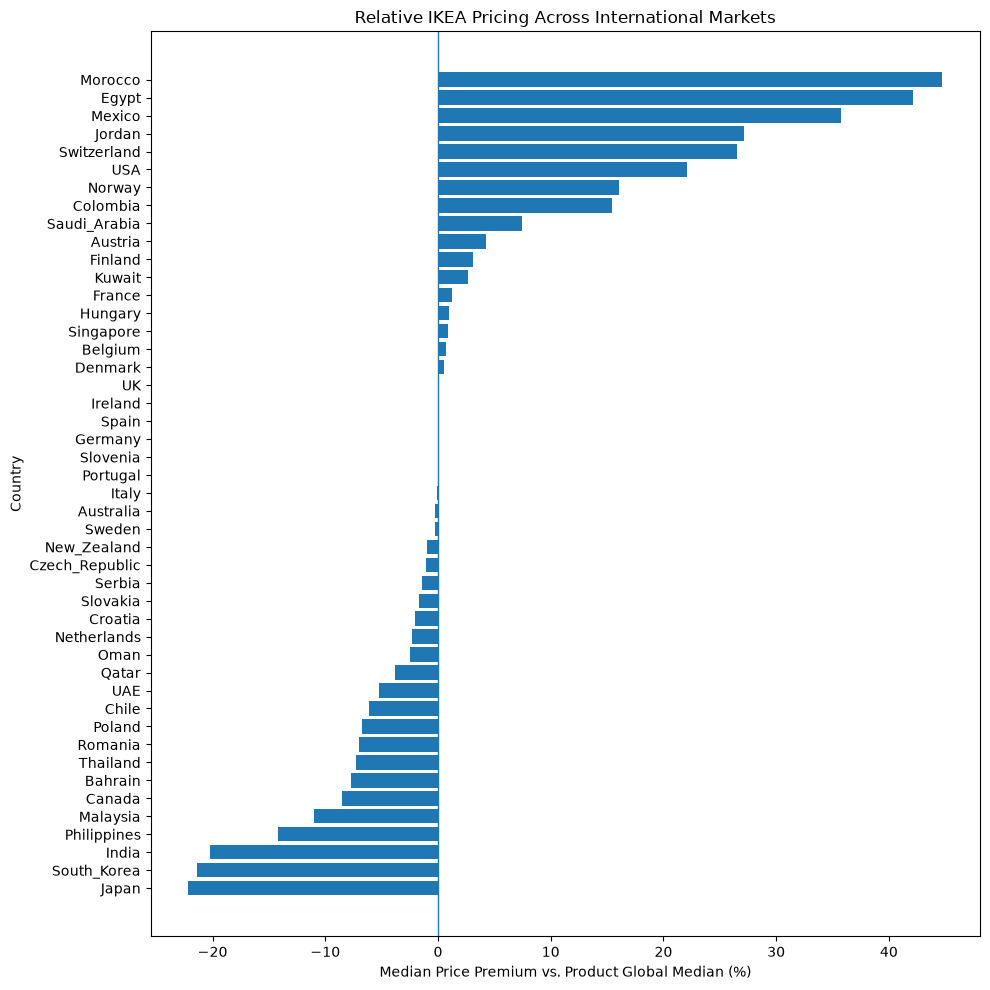

In [91]:
plot_df = (
    country_price_summary
    .sort_values("median_price_premium_pct")
)

plt.figure(figsize=(10, 10))

plt.barh(
    plot_df["country"],
    plot_df["median_price_premium_pct"]
)

plt.axvline(0, linewidth=1)

plt.xlabel(
    "Median Price Premium vs. Product Global Median (%)"
)

plt.ylabel("Country")

plt.title(
    "Relative IKEA Pricing Across International Markets"
)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig('')

In [92]:
product_price_dispersion = (
    price_analysis
    .groupby("product_id")
    .agg(
        product_name=("product_name", "first"),
        markets=("country", "nunique"),
        min_price_usd=("price_usd", "min"),
        median_price_usd=("price_usd", "median"),
        max_price_usd=("price_usd", "max")
    )
    .reset_index()
)

In [93]:
product_price_dispersion[
    "relative_price_range_pct"
] = (
    (
        product_price_dispersion["max_price_usd"]
        - product_price_dispersion["min_price_usd"]
    )
    / product_price_dispersion["median_price_usd"]
) * 100

In [94]:
product_price_dispersion

,product_id,product_name,markets,min_price_usd,median_price_usd,max_price_usd,relative_price_range_pct
0,28508,LEN,46,2.651,5.172,11.483,170.746
1,31841,EDSVIK,34,43.150,65.517,155.643,171.699
2,58487,FLYTTA,16,162.037,201.535,246.116,41.719
3,69768,OMAR,37,17.993,34.425,57.460,114.644
4,81534,KONCIS,46,2.753,5.743,9.950,125.323
...,...,...,...,...,...,...,...
17524,99924781,METOD,15,241.954,290.805,437.147,67.122
17525,99925653,METOD,7,260.920,317.643,557.096,93.242
17526,99929241,RÄCKA,24,5.856,11.903,26.391,172.517
17527,99929585,RÄCKA / HUGAD,37,22.891,47.784,71.218,101.137


## 6. Customer Rating Reliability

In [96]:
C = rating_df["product_rating"].mean()

In [97]:
m = rating_df[
    "product_rating_count"
].median()

C, m

(np.float64(4.455271177244449), np.float64(18.0))

In [98]:
R = rating_df["product_rating"]
v = rating_df["product_rating_count"]

rating_df["weighted_rating"] = (
    (v / (v + m)) * R
    + (m / (v + m)) * C
)

In [99]:
MIN_REVIEWS = 50

In [100]:
value_df = rating_df[
    rating_df["product_rating_count"]
    >= MIN_REVIEWS
].copy()